# Supplementary Jiang24 PCC analysis

Reproduces PCC-on-DEG benchmark summaries for the Jiang24 seen and unseen perturbation settings.


In [1]:
# Set to True to write image files to figures/supplement/output/.
SAVE_FIGURES = False

## PCC benchmark summary


Seen perturbation setting
Median PCC on DEGs:
TranScouter    0.716081
scGen          0.632175
trVAE          0.652198
Avg            0.217418


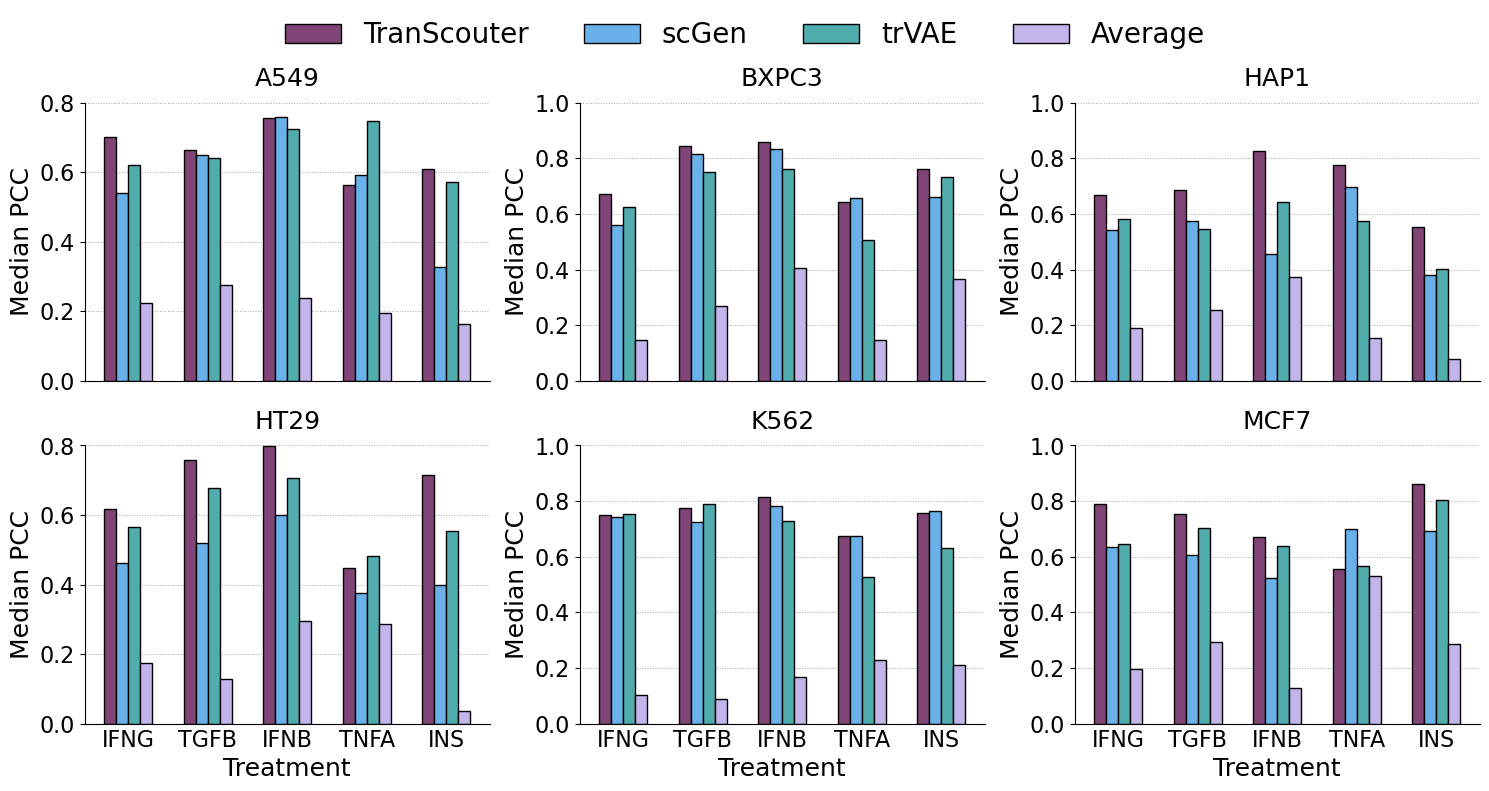

Unseen perturbation setting
Median PCC on DEGs:
TranScouter    0.701832
Correlation    0.544892
CellOracle     0.848179
Avg            0.190105


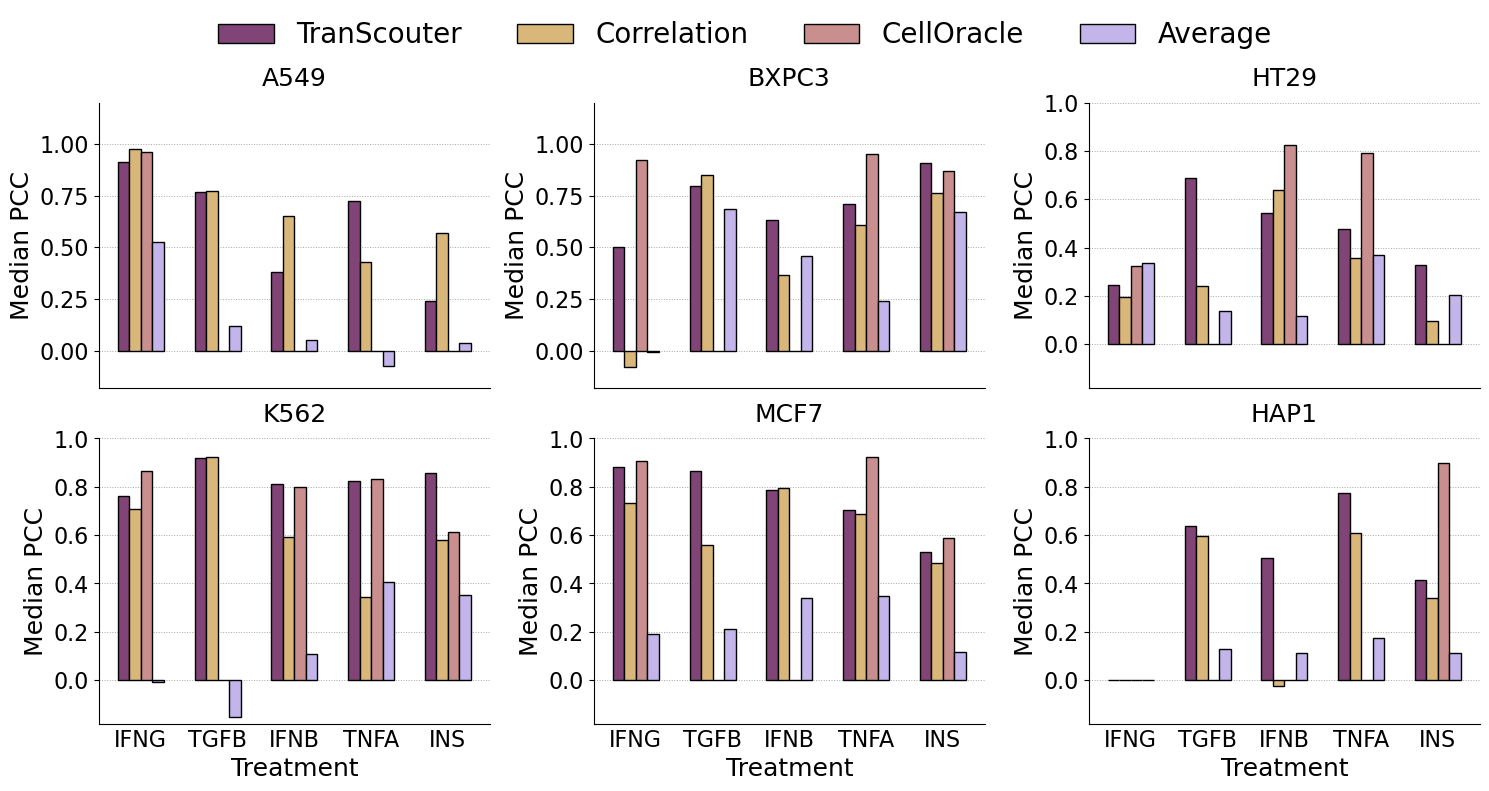

In [2]:
import pickle
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
from pathlib import Path
ROOT = Path.cwd().resolve()
while not ((ROOT / "transcouter").is_dir() and (ROOT / "code").is_dir() and (ROOT / "figures").is_dir()) and ROOT.parent != ROOT:
    ROOT = ROOT.parent
if not ((ROOT / "transcouter").is_dir() and (ROOT / "code").is_dir() and (ROOT / "figures").is_dir()):
    raise RuntimeError("Run this notebook from inside the TranScouter repository")
os.chdir(ROOT)
Path("figures/main/output").mkdir(parents=True, exist_ok=True)
Path("figures/supplement/output").mkdir(parents=True, exist_ok=True)

# fmt: off
SCENARIOS = {
    "seen": {
        "label": "Seen perturbation setting",
        "results_path": "results/collected/jiang/seen_pred_results.pkl",
        "method_cols": ["TranScouter", "scGen", "trVAE", "Avg"],
        "display_names": ["TranScouter", "scGen", "trVAE", "Average"],
        "save_prefix": "figures/supplement/output/supp_jiang_pcc_seen",
        "ymin": 0,
    },
    "unseen": {
        "label": "Unseen perturbation setting",
        "results_path": "results/collected/jiang/unseen_pred_results.pkl",
        "method_cols": ["TranScouter", "Correlation", "CellOracle", "Avg"],
        "display_names": ["TranScouter", "Correlation", "CellOracle", "Average"],
        "save_prefix": "figures/supplement/output/supp_jiang_pcc_unseen",
        "ymin": -0.18,
    },
}

method_colors = {
    "TranScouter": "#814476",
    "Avg": "#c3b5ea",
    "scGen": "#6ab1e9",
    "trVAE": "#50acad",
    "Correlation": "#d9b77a",
    "CellOracle": "#c98f8f",
}
# fmt: on

with open("data/jiang/processed/top_degs_names.pkl", "rb") as f:
    top_degs_names = pickle.load(f)


def safe_pearsonr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    keep = np.isfinite(x) & np.isfinite(y)
    x = x[keep]
    y = y[keep]
    if x.size < 2 or np.all(x == x[0]) or np.all(y == y[0]):
        return np.nan
    return pearsonr(x, y)[0]


def compute_pcc_degs(results, method_cols):
    true = results["True"]
    preds = {name: results[name] for name in method_cols}
    metrics = {"PCC_degs": {name: {} for name in preds}}

    for cov_pert in preds["TranScouter"].index:
        degs = top_degs_names[cov_pert]
        true_i = true.loc[cov_pert]

        for name, df in preds.items():
            if cov_pert not in df.index:
                continue
            pred_i = df.loc[cov_pert]

            if len(degs) > 10:
                metrics["PCC_degs"][name][cov_pert] = safe_pearsonr(true_i[degs], pred_i[degs])

    return pd.DataFrame(metrics["PCC_degs"])


def plot_celltype_panels(df, method_cols, display_names, colors, save_prefix=None, ymin=0):
    df = df.assign(covariate=df.index.to_series().str.split("_", expand=True)[0])
    df[["celltype", "treatment"]] = df.covariate.str.split("+", expand=True)
    df["celltype"] = df["celltype"].str.upper()

    celltypes = df["celltype"].unique()
    treatments = df["treatment"].unique()

    agg = df.groupby(["celltype", "treatment"], observed=False)[method_cols].median().reset_index()

    plt.rcParams.update({
        "axes.titlesize": 18,
        "axes.labelsize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 16,
    })
    fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
    axes = axes.ravel()

    for ax, ct in zip(axes, celltypes):
        sub = (
            agg[agg["celltype"] == ct]
            .set_index("treatment")
            .reindex(treatments)
        )

        sub[method_cols].plot(
            kind="bar", ax=ax, color=colors,
            width=0.6, edgecolor="black", legend=False,
        )

        yticks = ax.get_yticks()
        ymax = yticks[-2] if sub[method_cols].values.max() <= yticks[-2] else yticks[-1]
        ymin_val = sub[method_cols].values.min() if ymin == "adap" else ymin
        ax.set_ylim(ymin_val, ymax)
        ax.yaxis.grid(True, linestyle=":", linewidth=0.7, color="gray", alpha=0.7)
        ax.set_axisbelow(True)
        ax.spines["right"].set_visible(False)
        ax.spines["top"].set_visible(False)

        ax.set_title(f"{ct}", pad=12)
        ax.set_xlabel("Treatment")
        ax.set_ylabel("Median PCC")
        ax.set_xticklabels(sub.index, rotation=0, ha="center")
        ax.tick_params(axis="x", length=0)

    for j in range(len(celltypes), len(axes)):
        axes[j].axis("off")

    handles = [mpatches.Patch(facecolor=c, edgecolor="black") for c in colors]
    fig.legend(
        handles, display_names,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.0),
        ncol=len(display_names),
        fontsize=20,
        frameon=False,
    )

    plt.tight_layout(rect=(0, 0, 1, 0.93))
    if globals().get("SAVE_FIGURES", False) and save_prefix:
        filename = f"{save_prefix}.png"
        fig.savefig(filename, dpi=300, bbox_inches="tight")
        print(f"Saved: {filename}")
    plt.show()


for scenario, cfg in SCENARIOS.items():
    print(cfg["label"])
    with open(cfg["results_path"], "rb") as f:
        results = pickle.load(f)

    colors = [method_colors[name] for name in cfg["method_cols"]]
    PCC_degs = compute_pcc_degs(results, cfg["method_cols"])

    print("Median PCC on DEGs:")
    print(PCC_degs.median().to_string())

    plot_celltype_panels(
        PCC_degs,
        cfg["method_cols"],
        cfg["display_names"],
        colors,
        save_prefix=cfg["save_prefix"],
        ymin=cfg["ymin"],
    )
